TAHAP 1: SIMULASI DATA SPASIAL
INFORMASI DATA ZINC

Statistik Zinc Asli:
count     155.000000
mean      469.716129
std       367.073788
min       113.000000
25%       198.000000
50%       326.000000
75%       674.500000
max      1839.000000
Name: zinc, dtype: float64

Statistik Log Zinc:
count    155.000000
mean       5.889266
std        0.719804
min        4.736198
25%        5.293305
50%        5.789960
75%        6.515451
max        7.517521
Name: log_zinc, dtype: float64

Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   x         155 non-null    int64  
 1   y         155 non-null    int64  
 2   zinc      155 non-null    int64  
 3   log_zinc  155 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 5.0 KB
None

5 Data Awal:
        x       y  zinc  log_zinc
0  181072  333611  1022  6.930495
1  181025  333558  1141  7.0

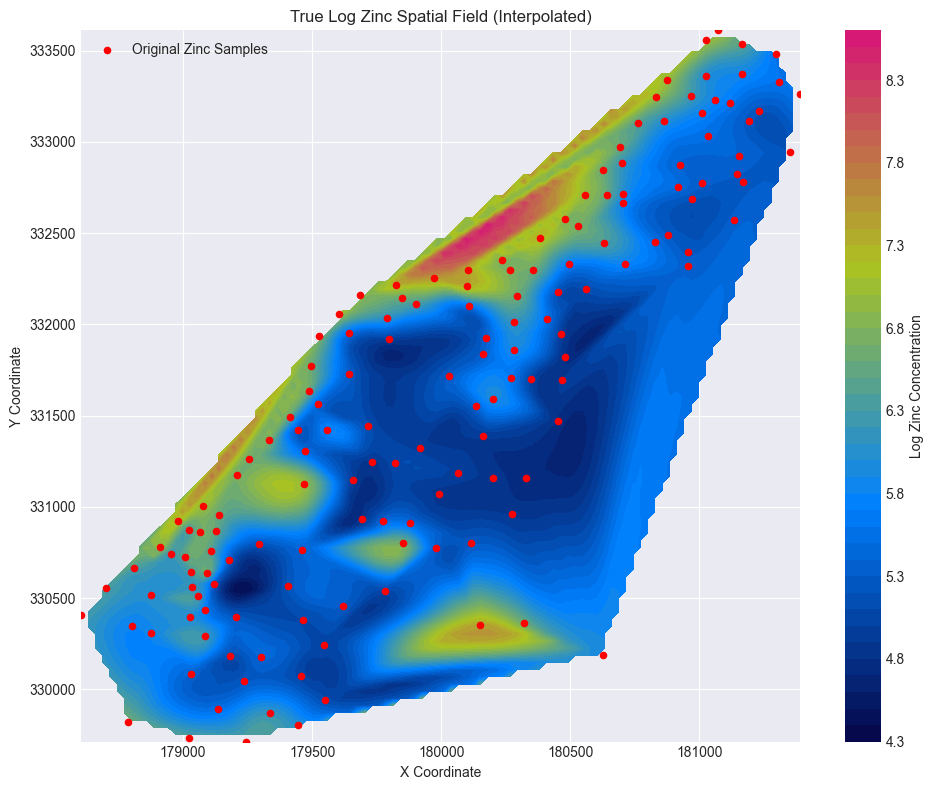

In [25]:
# =============================================================================
# 1. IMPORT LIBRARY
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from pykrige.ok import OrdinaryKriging
from pykrige.kriging_tools import write_asc_grid

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# =============================================================================
# 2. SIMULASI DATA SPASIAL DENGAN STRUKTUR AUTOKORELASI
# =============================================================================

print("="*80)
print("TAHAP 1: SIMULASI DATA SPASIAL")
print("="*80)

# =============================================================================
# Membaca data penelitian Zinc
# =============================================================================

data = pd.read_excel(
    "soil.xlsx"
)

# =============================================================================
# INFORMASI DATA ZINC
# =============================================================================

print("="*80)
print("INFORMASI DATA ZINC")
print("="*80)

print("\nStatistik Zinc Asli:")
print(
    data["zinc"].describe()
)

print("\nStatistik Log Zinc:")
print(
    data["log_zinc"].describe()
)

print("\nInformasi Data:")
print(
    data.info()
)

print("\n5 Data Awal:")
print(
    data.head()
)

# =============================================================================
# PEMBENTUKAN GRID SPASIAL
# =============================================================================

# jumlah grid simulasi
nx = 100
ny = 100

# Membuat koordinat grid
grid_x = np.linspace(
    data["x"].min(),
    data["x"].max(),
    nx
)

grid_y = np.linspace(
    data["y"].min(),
    data["y"].max(),
    ny
)

X, Y = np.meshgrid(
    grid_x,
    grid_y
)
print("\nParameter Grid:")

print(
    f"Grid : {nx} x {ny}"
)
print(
    f"Jumlah titik grid : {nx*ny:,}"
)

# =============================================================================
# INTERPOLASI LOG ZINC MENJADI TRUE FIELD
# =============================================================================

from scipy.interpolate import griddata
true_field_zinc = griddata(
    (
        data["x"],
        data["y"]
    ),
    # menggunakan data yang sudah dilogaritmakan
    data["log_zinc"],
    (
        X,
        Y
    ),
    method="cubic"
)
print("\nStatistik Spatial Field Log Zinc:")
print(
    f"Mean : {np.nanmean(true_field_zinc):.3f}"
)
print(
    f"Std Dev : {np.nanstd(true_field_zinc):.3f}"
)
print(
    f"Min : {np.nanmin(true_field_zinc):.3f}"
)
print(
    f"Max : {np.nanmax(true_field_zinc):.3f}"
)

# =============================================================================
# VISUALISASI TRUE SPATIAL FIELD
# =============================================================================

from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
      "blue_fuchsia",
        [
            "#060647",
            "#0080FF",
            "#ABC320",
            "#D71576"
        ]
    )
plt.figure(figsize=(10,8))
contour = plt.contourf(
    X,
    Y,
    true_field_zinc,
    levels=50,
    cmap=custom_cmap
)
plt.scatter(
    data["x"],
    data["y"],
    c="red",
    s=20,
    label="Original Zinc Samples"
)
plt.colorbar(
    contour,
    label="Log Zinc Concentration"
)
plt.xlabel(
    "X Coordinate"
)
plt.ylabel(
    "Y Coordinate"
)
plt.title(
    "True Log Zinc Spatial Field (Interpolated)"
)
plt.legend()
plt.tight_layout()
plt.show()


TAHAP 2: SAMPLING DATA
Jumlah titik observasi:
100

Statistik Sampel Zinc:
Mean : 5.724
Std  : 0.712

Data Sampling:
               x              y  zinc_true  zinc_observed
0  179026.969697  329950.181818   5.385182       5.393533
1  179223.888889  329871.454545   5.908829       5.900939
2  180574.191919  333059.909091   7.450336       7.357917
3  179955.303030  332272.636364   7.686739       7.677605
4  180377.272727  332272.636364   6.376976       6.384640


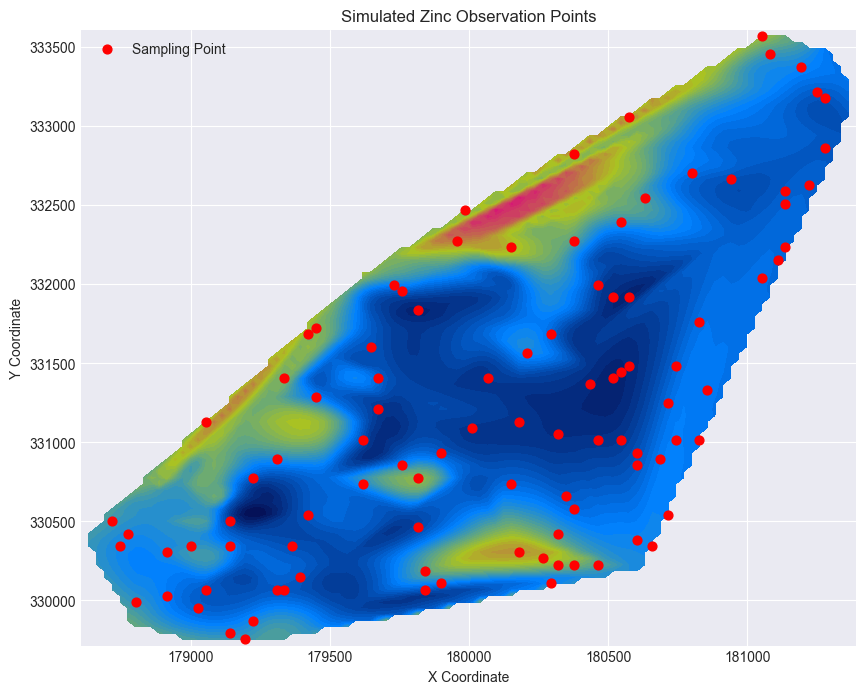

In [26]:
# =============================================================================
# 3. SAMPLING DATA (SIMULASI OBSERVASI)
# =============================================================================

print("\n" + "="*80)
print("TAHAP 2: SAMPLING DATA")
print("="*80)

# Jumlah titik observasi simulasi
n_samples = 100

# Menghilangkan nilai kosong hasil interpolasi
valid_mask = ~np.isnan(true_field_zinc.flatten())

# indeks lokasi yang valid
valid_indices = np.where(valid_mask)[0]

# memilih titik observasi secara random
np.random.seed(42)
sample_indices = np.random.choice(
    valid_indices,
    n_samples,
    replace=False
)

# Mengambil koordinat sampel
sample_x = X.flatten()[sample_indices]
sample_y = Y.flatten()[sample_indices]

# Mengambil nilai zinc sebenarnya
sample_zinc = true_field_zinc.flatten()[sample_indices]

print("Jumlah titik observasi:")
print(len(sample_zinc))

# =============================================================================
# MENAMBAHKAN ERROR PENGUKURAN
# =============================================================================

noise_std = 0.05 * np.std(sample_zinc)
sample_zinc_noisy = (
    sample_zinc +
    np.random.normal(
        0,
        noise_std,
        n_samples
    )
)
print("\nStatistik Sampel Zinc:")
print(
    f"Mean : {sample_zinc_noisy.mean():.3f}"
)
print(
    f"Std  : {sample_zinc_noisy.std():.3f}"
)

# =============================================================================
# DATA OBSERVASI HASIL SAMPLING
# =============================================================================
sample_data = pd.DataFrame({
    "x": sample_x,
    "y": sample_y,
    "zinc_true": sample_zinc,
    "zinc_observed": sample_zinc_noisy
})
print("\nData Sampling:")
print(sample_data.head())

# =============================================================================
# VISUALISASI TITIK OBSERVASI
# =============================================================================

custom_cmap = LinearSegmentedColormap.from_list(
    "blue_fuchsia",
    [
        "#060647",
        "#0080FF",
        "#ABC320",
        "#D71576"
    ]
)
plt.figure(figsize=(10,8))
plt.contourf(
    X,
    Y,
    true_field_zinc,
    levels=50,
    cmap=custom_cmap
)

plt.scatter(
    sample_x,
    sample_y,
    c="red",
    s=40,
    label="Sampling Point"
)
plt.colorbar(
    contour,
    label="Zinc"
)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title(
    "Simulated Zinc Observation Points"
)
plt.legend()
plt.show()


TAHAP 3: ANALISIS VARIOGRAM
Jumlah titik observasi:
100
Ukuran matriks jarak:
(100, 100)
Jumlah pasangan titik:
4950
      distance  semivariance
0   212.073458      0.128730
1  3473.370167      1.929401
2  2501.119328      2.608492
3  2686.468572      0.491146
4  2018.482884      0.067157
   distance_mean  semivariance_mean  pair_count
0     143.943199           0.145571         114
1     339.573163           0.369262         273
2     532.549505           0.381631         401
3     746.093141           0.558362         459
4     952.467477           0.592861         513


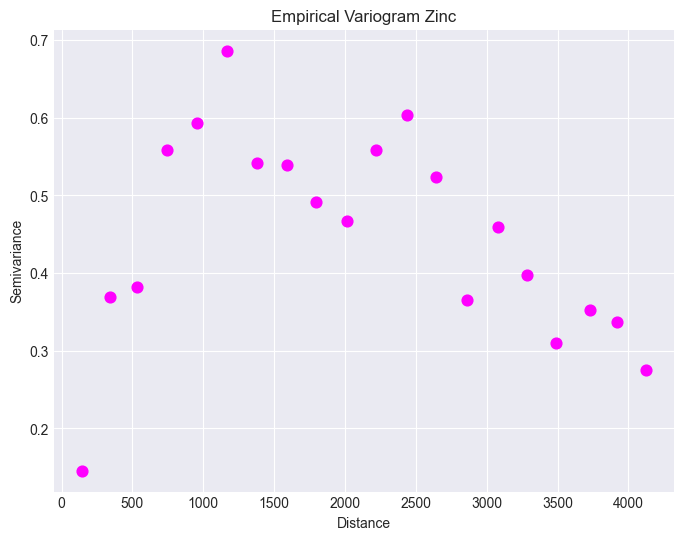

In [27]:
# =============================================================================
# 4. ANALISIS VARIOGRAM
# =============================================================================

print("\n" + "="*80)
print("TAHAP 3: ANALISIS VARIOGRAM")
print("="*80)

# Koordinat titik observasi
coords = np.column_stack(
    (
        sample_data["x"],
        sample_data["y"]
    )
)

# Nilai zinc hasil pengamatan
values = sample_data["zinc_observed"].values

print("Jumlah titik observasi:")
print(len(values))

# Matriks jarak antar titik
distance_matrix = squareform(
    pdist(coords)
)

print("Ukuran matriks jarak:")
print(distance_matrix.shape)

# Menyimpan hasil variogram
variogram_data = []

for i in range(len(values)):
    for j in range(i+1, len(values)):
        distance = distance_matrix[i,j]
        semivariance = (
            (values[i]-values[j])**2
        ) / 2
        variogram_data.append(
            [
                distance,
                semivariance
            ]
        )

print(
    "Jumlah pasangan titik:"
)
print(
    len(variogram_data)
)
variogram_df = pd.DataFrame(
    variogram_data,
    columns=[
        "distance",
        "semivariance"
    ]
)
print(
    variogram_df.head()
)

# =============================================================================
# PEMBENTUKAN LAG VARIOGRAM
# =============================================================================

n_lags = 20
max_distance = variogram_df["distance"].max()
bins = np.linspace(
    0,
    max_distance,
    n_lags+1
)
variogram_df["lag"] = pd.cut(
    variogram_df["distance"],
    bins=bins
)
empirical_variogram = (
    variogram_df
    .groupby("lag", observed=True)
    .agg(
        distance_mean=("distance","mean"),
        semivariance_mean=("semivariance","mean"),
        pair_count=("semivariance","count")
    )
    .reset_index(drop=True)
)
print(
    empirical_variogram.head()
)

# =============================================================================
# VISUALISASI VARIOGRAM EMPIRIS
# =============================================================================

plt.figure(figsize=(8,6))
plt.scatter(
    empirical_variogram["distance_mean"],
    empirical_variogram["semivariance_mean"],
    s=60,
    color="#FF00FF"
)
plt.xlabel(
    "Distance"
)
plt.ylabel(
    "Semivariance"
)
plt.title(
    "Empirical Variogram Zinc"
)
plt.grid(True)
plt.show()


TAHAP 4: FITTING MODEL VARIOGRAM TEORITIS
Jumlah lag variogram:
20


Parameter Exponential:
[ -0.33977805   0.81067468 159.50347232]

Parameter Spherical:
[4.26478144e-02 4.30648541e-01 7.46025448e+02]

Parameter Gaussian:
[8.24752943e-02 3.89077518e-01 3.24138167e+02]

Nilai SSE Model:
Exponential : 0.2259993330259476
Spherical : 0.22513019895592454
Gaussian : 0.2253218643857461

Model terbaik:
Spherical


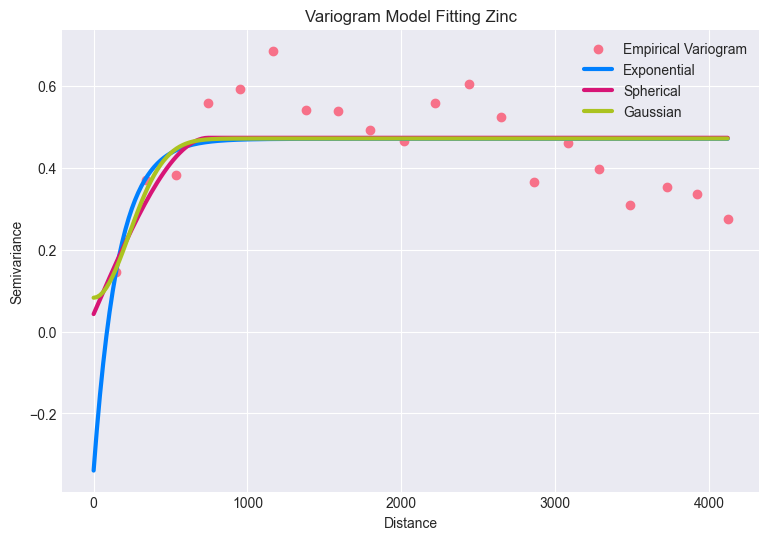

In [28]:
# =============================================================================
# 5. FITTING MODEL VARIOGRAM TEORITIS
# =============================================================================

print("\n" + "="*80)
print("TAHAP 4: FITTING MODEL VARIOGRAM TEORITIS")
print("="*80)

# Data jarak dan semivariance
distance = empirical_variogram["distance_mean"].values
gamma = empirical_variogram["semivariance_mean"].values

print("Jumlah lag variogram:")
print(len(distance))

# =============================================================================
# MODEL EXPONENTIAL
# =============================================================================

def variogram_exponential(
    h,
    nugget,
    sill,
    range_param
):
    return (
        nugget +
        sill *
        (
            1 -
            np.exp(
                -h/range_param
            )
        )
    )

# =============================================================================
# MODEL SPHERICAL
# =============================================================================

def variogram_spherical(
    h,
    nugget,
    sill,
    range_param
):
    gamma = np.zeros(len(h))
    for i, distance in enumerate(h):
        if distance <= range_param:
            gamma[i] = (
                nugget +
                sill *
                (
                    1.5*(distance/range_param)
                    -
                    0.5*(distance/range_param)**3
                )
            )
        else:
            gamma[i] = nugget + sill
    return gamma

# =============================================================================
# MODEL GAUSSIAN
# =============================================================================

def variogram_gaussian(
    h,
    nugget,
    sill,
    range_param
):
    return (
        nugget +
        sill *
        (
            1 -
            np.exp(
                -(h**2) /
                (range_param**2)
            )
        )
    )

# =============================================================================
# FITTING MODEL
# =============================================================================

initial_guess = [
    0.1,                     # nugget
    np.var(values),           # sill
    np.mean(distance)         # range
]

def fit_model(model_function):
    result = minimize(
        lambda params:
        np.sum(
            (
                gamma -
                model_function(
                    distance,
                    params[0],
                    params[1],
                    params[2]
                )
            )**2
        ),
        initial_guess,
        method="Nelder-Mead"
    )
    return result.x

# Fit semua model
params_exp = fit_model(
    variogram_exponential
)
params_sph = fit_model(
    variogram_spherical
)
params_gauss = fit_model(
    variogram_gaussian
)

print("Parameter Exponential:")
print(params_exp)
print("\nParameter Spherical:")
print(params_sph)
print("\nParameter Gaussian:")
print(params_gauss)

# =============================================================================
# PERBANDINGAN MODEL
# =============================================================================

def calculate_sse(
    model_function,
    params
):
    prediction = model_function(
        distance,
        params[0],
        params[1],
        params[2]
    )
    return np.sum(
        (
            gamma -
            prediction
        )**2
    )

sse_values = {
    "Exponential":
    calculate_sse(
        variogram_exponential,
        params_exp
    ),

    "Spherical":
    calculate_sse(
        variogram_spherical,
        params_sph
    ),

    "Gaussian":
    calculate_sse(
        variogram_gaussian,
        params_gauss
    )
}

print("\nNilai SSE Model:")
for model, error in sse_values.items():
    print(
        model,
        ":",
        error
    )

# Model dengan SSE terkecil
best_model = min(
    sse_values,
    key=sse_values.get
)

print(
    "\nModel terbaik:"
)

print(
    best_model
)

# =============================================================================
# VISUALISASI FITTING
# =============================================================================

plt.figure(figsize=(9,6))
plt.scatter(
    distance,
    gamma,
    label="Empirical Variogram"
)
h_line = np.linspace(
    0,
    max(distance),
    200
)

# Exponential Model
plt.plot(
    h_line,
    variogram_exponential(
        h_line,
        *params_exp
    ),
    color="#0080FF",  
    linewidth=3,
    label="Exponential"
)

#Spherical Model
plt.plot(
    h_line,
    variogram_spherical(
        h_line,
        *params_sph
    ),
    color="#D71576",
    linewidth=3,
    label="Spherical"
)

#Gaussian Model
plt.plot(
    h_line,
    variogram_gaussian(
        h_line,
        *params_gauss
    ),
    color="#ABC320",
    linewidth=3,
    label="Gaussian"
)
plt.xlabel(
    "Distance"
)
plt.ylabel(
    "Semivariance"
)
plt.title(
    "Variogram Model Fitting Zinc"
)
plt.legend()
plt.grid(True)
plt.show()


TAHAP 5: ORDINARY KRIGING PREDICTION
Model Kriging yang digunakan:
spherical
Model Ordinary Kriging berhasil dibuat
Prediksi selesai
Ukuran hasil prediksi:
(100, 100)
Ukuran kriging variance:
(100, 100)
               x         y  zinc_prediction  kriging_variance
0  178605.000000  329714.0         6.016455          0.426540
1  178633.131313  329714.0         6.019520          0.419823
2  178661.262626  329714.0         6.021827          0.413019
3  178689.393939  329714.0         6.023383          0.406178
4  178717.525253  329714.0         6.024210          0.399344


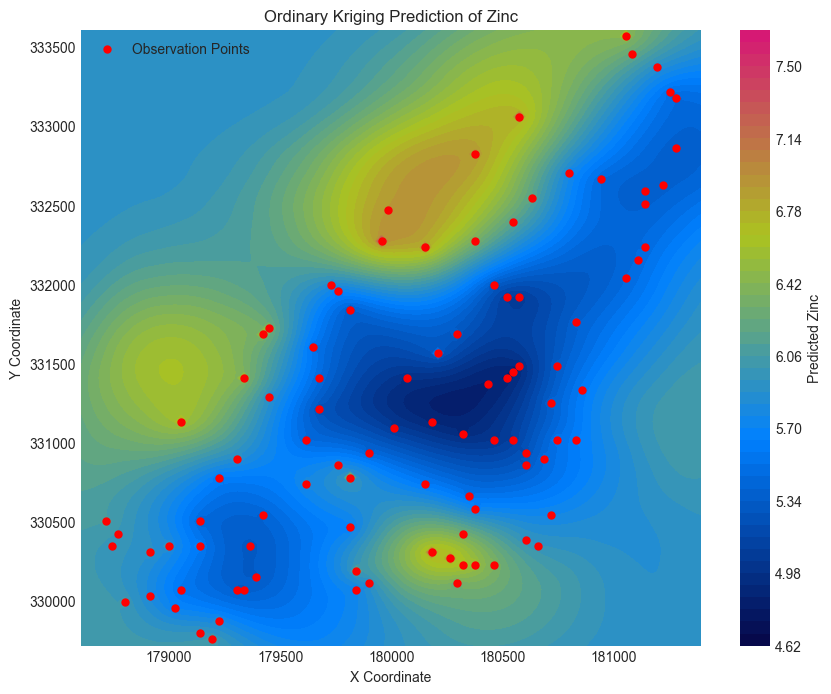

In [29]:
# =============================================================================
# 6. ORDINARY KRIGING PREDICTION
# =============================================================================

print("\n" + "="*80)
print("TAHAP 5: ORDINARY KRIGING PREDICTION")
print("="*80)

# =============================================================================
# MENYESUAIKAN MODEL VARIOGRAM
# =============================================================================
if best_model == "Exponential":
    kriging_model = "exponential"

elif best_model == "Spherical":
    kriging_model = "spherical"

elif best_model == "Gaussian":
    kriging_model = "gaussian"

print(
    "Model Kriging yang digunakan:"
)
print(
    kriging_model
)

# =============================================================================
# MEMBANGUN MODEL ORDINARY KRIGING
# =============================================================================

OK = OrdinaryKriging(
    sample_data["x"],
    sample_data["y"],
    sample_data["zinc_observed"],
    variogram_model=kriging_model,
    verbose=False,
    enable_plotting=False
)
print(
    "Model Ordinary Kriging berhasil dibuat"
)

# =============================================================================
# PREDIKSI GRID SPASIAL
# =============================================================================

z_pred, variance = OK.execute(
    "grid",
    grid_x,
    grid_y
)
print(
    "Prediksi selesai"
)
print(
    "Ukuran hasil prediksi:"
)
print(
    z_pred.shape
)
print(
    "Ukuran kriging variance:"
)
print(
    variance.shape
)

# =============================================================================
# MENYIMPAN HASIL PREDIKSI
# =============================================================================

X_pred, Y_pred = np.meshgrid(
    grid_x,
    grid_y
)
prediction_result = pd.DataFrame({
    "x":
    X_pred.flatten(),
    "y":
    Y_pred.flatten(),
    "zinc_prediction":
    z_pred.flatten(),
    "kriging_variance":
    variance.flatten()
})
print(
    prediction_result.head()
)

# =============================================================================
# VISUALISASI HASIL KRIGING
# =============================================================================

custom_cmap = LinearSegmentedColormap.from_list(
      "blue_fuchsia",
        [
            "#060647",
            "#0080FF",
            "#ABC320",
            "#D71576"
        ]
    )
plt.figure(figsize=(10,8))
prediction_plot = plt.contourf(
    X_pred,
    Y_pred,
    z_pred,
    levels=50,
    cmap=custom_cmap
)

plt.scatter(
    sample_data["x"],
    sample_data["y"],
    c="red",
    s=25,
    label="Observation Points"
)
plt.colorbar(
    prediction_plot,
    label="Predicted Zinc"
)
plt.xlabel(
    "X Coordinate"
)
plt.ylabel(
    "Y Coordinate"
)
plt.title(
    "Ordinary Kriging Prediction of Zinc"
)
plt.legend()
plt.show()

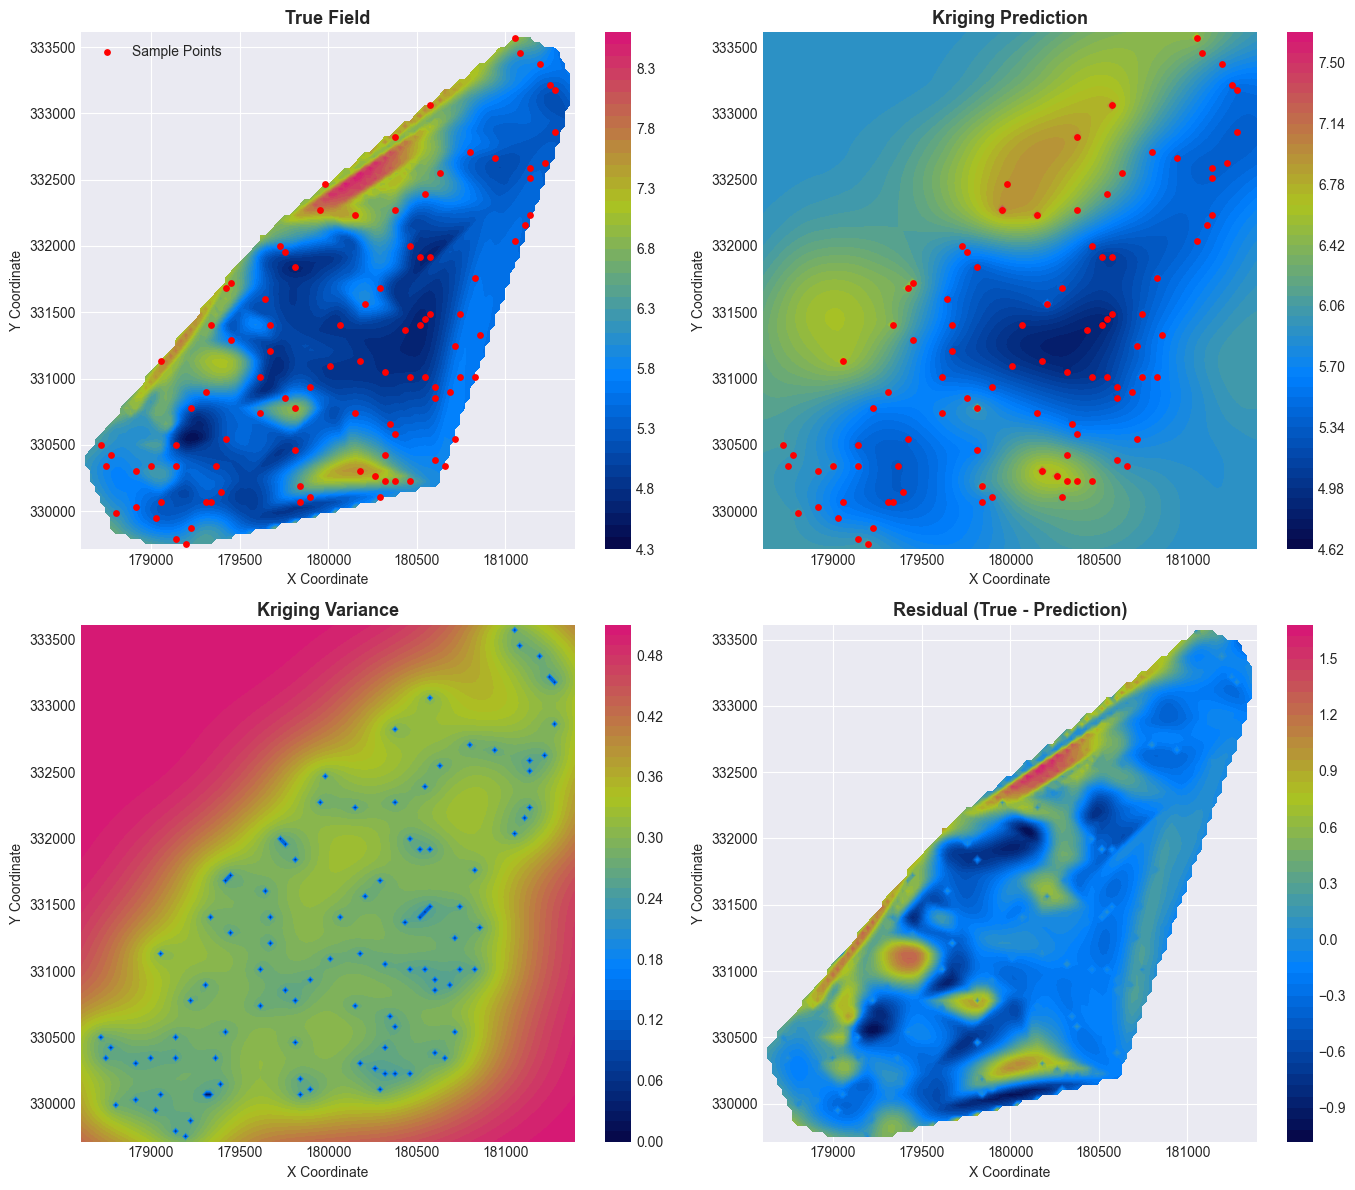

In [30]:
# =============================================================================
# 7. PERBANDINGAN TRUE FIELD VS KRIGING
# =============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,12)
)

# =============================================================================
#  TRUE FIELD
# =============================================================================

ax1 = axes[0,0]
plot1 = ax1.contourf(
    X,
    Y,
    true_field_zinc,
    levels=50,
    cmap=custom_cmap
)
ax1.scatter(
    sample_data["x"],
    sample_data["y"],
    c="red",
    s=15,
    label="Sample Points"
)
ax1.set_title(
    "True Field",
    fontsize=13,
    fontweight="bold"
)
ax1.set_xlabel(
    "X Coordinate"
)
ax1.set_ylabel(
    "Y Coordinate"
)
ax1.legend()
fig.colorbar(
    plot1,
    ax=ax1
)

# =============================================================================
# KRIGING PREDICTION
# =============================================================================

ax2 = axes[0,1]

plot2 = ax2.contourf(
    X_pred,
    Y_pred,
    z_pred,
    levels=50,
    cmap=custom_cmap
)
ax2.scatter(
    sample_data["x"],
    sample_data["y"],
    c="red",
    s=15
)
ax2.set_title(
    "Kriging Prediction",
    fontsize=13,
    fontweight="bold"
)
ax2.set_xlabel(
    "X Coordinate"
)
ax2.set_ylabel(
    "Y Coordinate"
)
fig.colorbar(
    plot2,
    ax=ax2
)

# =============================================================================
# KRIGING VARIANCE
# =============================================================================

ax3 = axes[1,0]
variance_cmap = LinearSegmentedColormap.from_list(
    "variance_blue_fuchsia",
    [
        "#060647",
        "#0080FF",
        "#ABC320",
        "#D71576"
    ]
)
plot3 = ax3.contourf(
    X_pred,
    Y_pred,
    np.array(variance),
    levels=50,
    cmap=variance_cmap
)
ax3.set_title(
    "Kriging Variance",
    fontsize=13,
    fontweight="bold"
)
ax3.set_xlabel(
    "X Coordinate"
)
ax3.set_ylabel(
    "Y Coordinate"
)
fig.colorbar(
    plot3,
    ax=ax3
)

# =============================================================================
# RESIDUAL (TRUE - PREDICTION)
# =============================================================================

ax4 = axes[1,1]
residual_cmap = LinearSegmentedColormap.from_list(
    "residual_blue_fuchsia",
    [ "#060647",
            "#0080FF",
            "#ABC320",
            "#D71576"
    ]
)
residual = (
    true_field_zinc -
    z_pred
)
plot4 = ax4.contourf(
    X_pred,
    Y_pred,
    residual,
    levels=50,
    cmap=residual_cmap
)
ax4.set_title(
    "Residual (True - Prediction)",
    fontsize=13,
    fontweight="bold"
)
ax4.set_xlabel(
    "X Coordinate"
)
ax4.set_ylabel(
    "Y Coordinate"
)
fig.colorbar(
    plot4,
    ax=ax4
)

plt.tight_layout()
plt.show()


TAHAP 7: VALIDASI DAN EVALUASI

Melakukan Leave-One-Out Cross Validation...

Hasil Cross-Validation (LOO)
RMSE : 0.4698
MAE  : 0.3526
R²   : 0.5644

Melakukan Validasi pada Seluruh Grid...

Hasil Validasi pada Seluruh Grid
RMSE : 0.4021
MAE  : 0.3033
R²   : 0.7119

Statistik Residual
Mean Residual : -0.0099
Std Residual : 0.402

SUMMARY PERFORMANCE
             Validation      RMSE       MAE        R2
0  LOO Cross Validation  0.469823  0.352645  0.564400
1       Grid Validation  0.402106  0.303287  0.711944


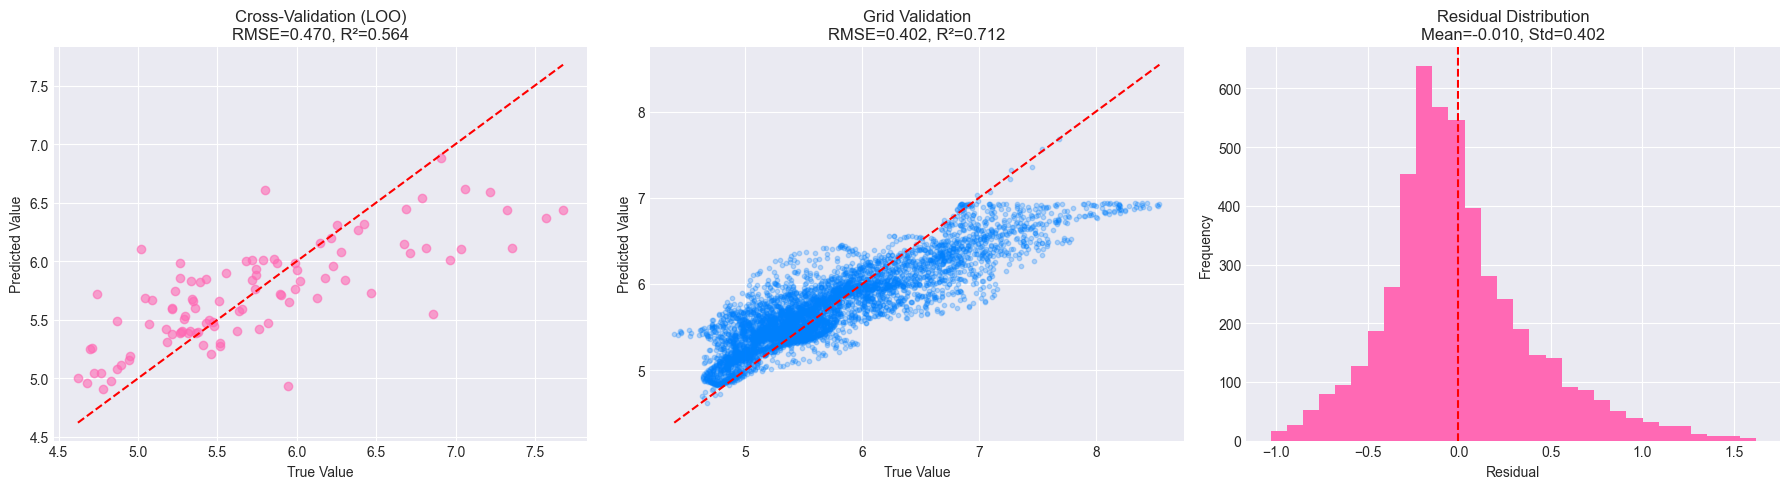

In [31]:
# =============================================================================
# 8. VALIDASI DAN EVALUASI PERFORMANCE
# =============================================================================

print("\n" + "="*80)
print("TAHAP 7: VALIDASI DAN EVALUASI")
print("="*80)

# =============================================================================
# 1. LEAVE-ONE-OUT CROSS VALIDATION (LOO)
# =============================================================================

print("\nMelakukan Leave-One-Out Cross Validation...")
loo_actual = []
loo_prediction = []
sample_validation = sample_data.copy()
for i in range(len(sample_validation)):

    # data training tanpa satu titik
    train_data = sample_validation.drop(
        sample_validation.index[i]
    )
    test_point = sample_validation.iloc[i]
    OK_loo = OrdinaryKriging(
        train_data["x"],
        train_data["y"],
        train_data["zinc_observed"],
        variogram_model=kriging_model,
        verbose=False,
        enable_plotting=False
    )
    pred, var = OK_loo.execute(
        "points",
        [test_point["x"]],
        [test_point["y"]]
    )
    loo_actual.append(
        test_point["zinc_observed"]
    )
    loo_prediction.append(
        pred[0]
    )
loo_actual = np.array(
    loo_actual
)
loo_prediction = np.array(
    loo_prediction
)

# metric LOO
rmse_loo = np.sqrt(
    mean_squared_error(
        loo_actual,
        loo_prediction
    )
)

mae_loo = mean_absolute_error(
    loo_actual,
    loo_prediction
)
r2_loo = r2_score(
    loo_actual,
    loo_prediction
)
print("\nHasil Cross-Validation (LOO)")
print(
"RMSE :",
round(rmse_loo,4)
)
print(
"MAE  :",
round(mae_loo,4)
)
print(
"R²   :",
round(r2_loo,4)
)

# =============================================================================
# 2. GRID VALIDATION
# =============================================================================

print("\nMelakukan Validasi pada Seluruh Grid...")
grid_actual = true_field_zinc.flatten()
grid_prediction = z_pred.flatten()
valid_grid = (
    ~np.isnan(grid_actual)
    &
    ~np.isnan(grid_prediction)
)
grid_actual = grid_actual[valid_grid]
grid_prediction = grid_prediction[valid_grid]

rmse_grid = np.sqrt(
    mean_squared_error(
        grid_actual,
        grid_prediction
    )
)
mae_grid = mean_absolute_error(
    grid_actual,
    grid_prediction
)
r2_grid = r2_score(
    grid_actual,
    grid_prediction
)
print("\nHasil Validasi pada Seluruh Grid")
print(
"RMSE :",
round(rmse_grid,4)
)
print(
"MAE  :",
round(mae_grid,4)
)
print(
"R²   :",
round(r2_grid,4)
)

# =============================================================================
# 3. RESIDUAL DISTRIBUTION
# =============================================================================

residual = (
    grid_actual -
    grid_prediction
)
print("\nStatistik Residual")
print(
"Mean Residual :",
round(np.mean(residual),4)
)
print(
"Std Residual :",
round(np.std(residual),4)
)

# =============================================================================
# SUMMARY PERFORMANCE
# =============================================================================

performance = pd.DataFrame({
    "Validation":
    [
        "LOO Cross Validation",
        "Grid Validation"
    ],

    "RMSE":
    [
        rmse_loo,
        rmse_grid
    ],

    "MAE":
    [
        mae_loo,
        mae_grid
    ],

    "R2":
    [
        r2_loo,
        r2_grid
    ]

})
print("\nSUMMARY PERFORMANCE")
print(performance)

# =============================================================================
# VISUALISASI VALIDASI
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

# =============================================================================
# LOO CROSS VALIDATION
# =============================================================================

axes[0].scatter(
    loo_actual,
    loo_prediction,
    color="#FF69B4",
    alpha=0.6
)
min_val = min(
    loo_actual.min(),
    loo_prediction.min()
)
max_val = max(
    loo_actual.max(),
    loo_prediction.max()
)
axes[0].plot(
    [min_val,max_val],
    [min_val,max_val],
    "--",
    color="red"
)
axes[0].set_title(
    f"Cross-Validation (LOO)\nRMSE={rmse_loo:.3f}, R²={r2_loo:.3f}"
)
axes[0].set_xlabel(
    "True Value"
)
axes[0].set_ylabel(
    "Predicted Value"
)

# =============================================================================
# GRID VALIDATION
# =============================================================================

axes[1].scatter(
    grid_actual,
    grid_prediction,
    color="#0080FF",
    alpha=0.25,
    s=10
)
axes[1].plot(
    [grid_actual.min(),grid_actual.max()],
    [grid_actual.min(),grid_actual.max()],
    "--",
    color="red"
)
axes[1].set_title(
    f"Grid Validation\nRMSE={rmse_grid:.3f}, R²={r2_grid:.3f}"
)
axes[1].set_xlabel(
    "True Value"
)
axes[1].set_ylabel(
    "Predicted Value"
)

# =============================================================================
# RESIDUAL DISTRIBUTION
# =============================================================================

axes[2].hist(
    residual,
    bins=30,
    color="#FF69B4"
)
axes[2].axvline(
    np.mean(residual),
    color="red",
    linestyle="--"
)
axes[2].set_title(
    f"Residual Distribution\nMean={np.mean(residual):.3f}, Std={np.std(residual):.3f}"
)
axes[2].set_xlabel(
    "Residual"
)
axes[2].set_ylabel(
    "Frequency"
)
plt.tight_layout()
plt.show()


TAHAP 8: ANALISIS KETIDAKPASTIAN

Statistik Kriging Variance:
Mean     : 0.3638
Std Dev  : 0.0908
Minimum  : -0.0000
Maximum  : 0.5044

Area dengan Ketidakpastian Tinggi:
Threshold Variance : 0.5022
Jumlah Grid        : 1,000
Persentase         : 10.00%


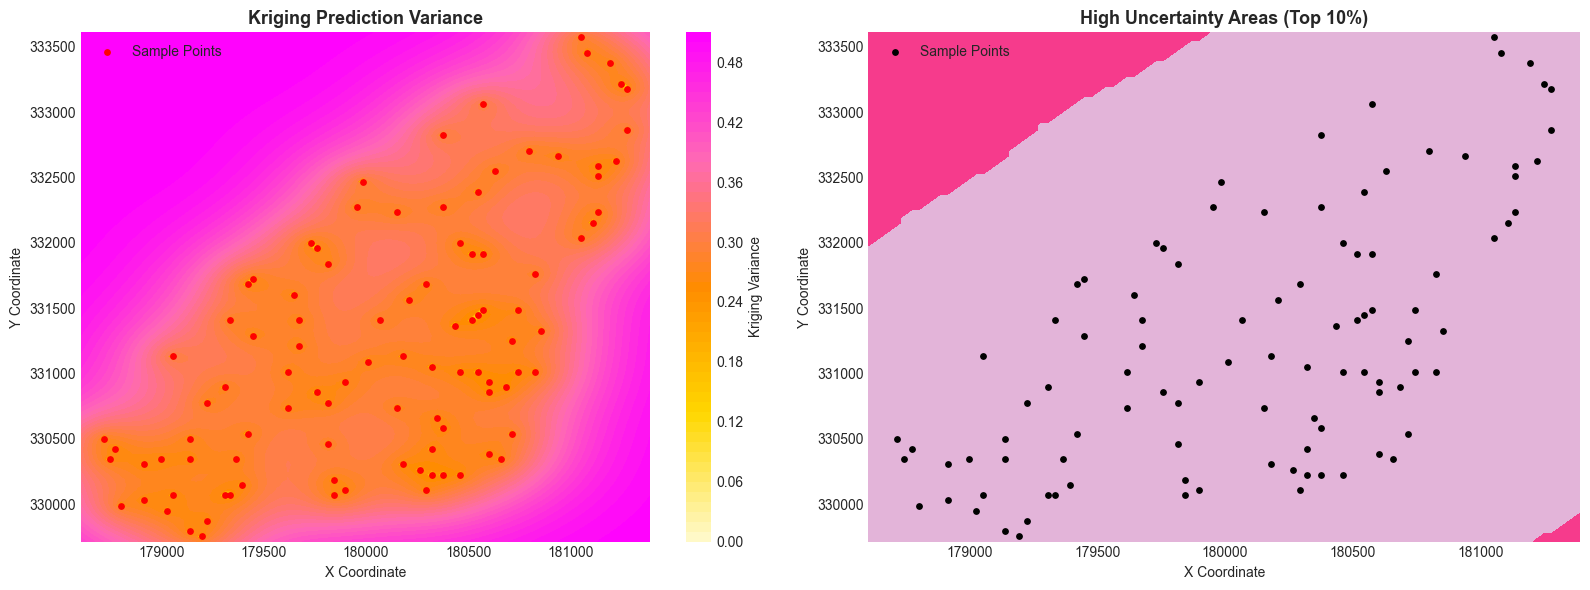


Statistik Kriging Standard Deviation:
Mean : 0.5964
Max  : 0.7102


In [32]:
# =============================================================================
# 9. ANALISIS KETIDAKPASTIAN
# =============================================================================

print("\n" + "="*80)
print("TAHAP 8: ANALISIS KETIDAKPASTIAN")
print("="*80)

# Mengubah hasil variance menjadi array numpy
kriging_variance = np.asarray(variance)

# =============================================================================
# STATISTIK KRIGING VARIANCE
# =============================================================================

print("\nStatistik Kriging Variance:")
print(
    f"Mean     : {np.nanmean(kriging_variance):.4f}"
)
print(
    f"Std Dev  : {np.nanstd(kriging_variance):.4f}"
)
print(
    f"Minimum  : {np.nanmin(kriging_variance):.4f}"
)
print(
    f"Maximum  : {np.nanmax(kriging_variance):.4f}"
)

# =============================================================================
# IDENTIFIKASI AREA DENGAN KETIDAKPASTIAN TINGGI
# =============================================================================

uncertainty_threshold = np.nanpercentile(
    kriging_variance,
    90
)
high_uncertainty_mask = (
    kriging_variance >
    uncertainty_threshold
)
n_high_uncertainty = np.sum(
    high_uncertainty_mask
)
percentage_high = (
    n_high_uncertainty /
    kriging_variance.size
) * 100

print("\nArea dengan Ketidakpastian Tinggi:")
print(
    f"Threshold Variance : {uncertainty_threshold:.4f}"
)
print(
    f"Jumlah Grid        : {n_high_uncertainty:,}"
)
print(
    f"Persentase         : {percentage_high:.2f}%"
)

# =============================================================================
# VISUALISASI KRIGING VARIANCE
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

# ============================================================================
# Plot 1 : Kriging Variance
# ============================================================================

variance_cmap = LinearSegmentedColormap.from_list(
    "variance_yellow_fuchsia",
    [
        "#FFFACD",  # rendah
        "#FFD700",  # sedang rendah
        "#FF8C00",  # sedang
        "#FF69B4",  # tinggi
        "#FF00FF"   # sangat tinggi
    ]
)
ax1 = axes[0]
variance_plot = ax1.contourf(
    X_pred,
    Y_pred,
    kriging_variance,
    levels=50,
    cmap=variance_cmap
)
ax1.scatter(
    sample_data["x"],
    sample_data["y"],
    c="red",
    s=15,
    label="Sample Points"
)
ax1.set_title(
    "Kriging Prediction Variance",
    fontsize=13,
    fontweight="bold"
)
ax1.set_xlabel(
    "X Coordinate"
)
ax1.set_ylabel(
    "Y Coordinate"
)
ax1.legend()
plt.colorbar(
    variance_plot,
    ax=ax1,
    label="Kriging Variance"
)

# ============================================================================
# Plot 2 : High Uncertainty Area
# ============================================================================

uncertainty_cmap = LinearSegmentedColormap.from_list(
    "uncertainty_area",
    [
        "#D9F0FF",  # uncertainty rendah
        "#FF0066"   # uncertainty tinggi
    ]
)
ax2 = axes[1]
uncertainty_plot = ax2.contourf(
    X_pred,
    Y_pred,
    high_uncertainty_mask.astype(int),
    levels=[
        -0.5,
        0.5,
        1.5
    ],
    cmap=uncertainty_cmap
)
ax2.scatter(
    sample_data["x"],
    sample_data["y"],
    c="black",
    s=15,
    label="Sample Points"
)
ax2.set_title(
    "High Uncertainty Areas (Top 10%)",
    fontsize=13,
    fontweight="bold"
)
ax2.set_xlabel(
    "X Coordinate"
)
ax2.set_ylabel(
    "Y Coordinate"
)
ax2.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# KRIGING STANDARD DEVIATION
# =============================================================================

kriging_std = np.sqrt(
    np.maximum(
        kriging_variance,
        0
    )
)
print("\nStatistik Kriging Standard Deviation:")
print(
    f"Mean : {np.nanmean(kriging_std):.4f}"
)
print(
    f"Max  : {np.nanmax(kriging_std):.4f}"
)

In [34]:
# =============================================================================
# 10. SUMMARY DAN KESIMPULAN
# =============================================================================

print("\n" + "="*80)
print("SUMMARY DAN KESIMPULAN")
print("="*80)

# =============================================================================
# RINGKASAN DATA
# =============================================================================

print("\nRINGKASAN DATA PENELITIAN")
print("-"*50)
print(
    f"""
Jumlah data awal Zinc      : {len(data)} titik
Jumlah titik simulasi      : {n_samples} titik
Ukuran grid prediksi       : {nx} x {ny}
Total lokasi prediksi      : {nx*ny:,} titik
Variabel yang dianalisis   : Zinc
"""
)

# =============================================================================
# MODEL VARIOGRAM
# =============================================================================

print("\nMODEL VARIOGRAM")
print("-"*50)
print(
    f"""
Model terbaik             : {best_model}
Nilai SSE terbaik         : {sse_values[best_model]:.4f}
"""
)

# =============================================================================
# PARAMETER MODEL TERBAIK
# =============================================================================

if best_model == "Exponential":
    best_params = params_exp
elif best_model == "Spherical":
    best_params = params_sph
elif best_model == "Gaussian":
    best_params = params_gauss
print(
    f"""
Parameter Model:
Nugget :
{best_params[0]:.4f}
Sill :
{best_params[1]:.4f}
Range :
{best_params[2]:.4f}
"""
)

# =============================================================================
# PERFORMANCE MODEL
# =============================================================================

print("\nPERFORMANCE ORDINARY KRIGING")
print("-"*50)
print(
    f"""
RMSE :
{rmse_grid:.4f}
MAE :
{mae_grid:.4f}
R² :
{r2_grid:.4f}
"""
)

# =============================================================================
# KETIDAKPASTIAN
# =============================================================================

print("\nANALISIS KETIDAKPASTIAN")
print("-"*50)
print(
    f"""
Mean Kriging Variance :
{np.nanmean(kriging_variance):.4f}
Maximum Kriging Variance :
{np.nanmax(kriging_variance):.4f}
Area uncertainty tinggi :
{percentage_high:.2f} %
"""
)

# =============================================================================
# KESIMPULAN
# =============================================================================

print("\nKESIMPULAN")
print("-"*50)

print(
f"""
Berdasarkan hasil analisis spasial menggunakan
metode Ordinary Kriging terhadap distribusi
kandungan Zinc, diperoleh bahwa:

1. Hasil analisis variogram menunjukkan bahwa
   data Zinc memiliki struktur autokorelasi spasial.
   Hubungan spasial antar titik observasi dapat
   dijelaskan melalui model variogram terbaik,
   yaitu model {best_model} dengan nilai SSE
   sebesar {sse_values[best_model]:.4f}.

2. Model variogram {best_model} memiliki parameter:
   Nugget = {best_params[0]:.4f},
   Sill = {best_params[1]:.4f},
   dan Range = {best_params[2]:.4f}.
   Nilai range menunjukkan bahwa pengaruh
   spasial Zinc masih terlihat hingga jarak
   tertentu pada wilayah penelitian.

3. Hasil interpolasi menggunakan Ordinary Kriging
   mampu menghasilkan distribusi spasial Zinc
   dengan performa evaluasi:
   RMSE = {rmse_grid:.4f},
   MAE  = {mae_grid:.4f},
   dan R² = {r2_grid:.4f}.
   Nilai R² menunjukkan bahwa model mampu
   menjelaskan sekitar {r2_grid*100:.2f}% variasi
   spasial Zinc pada area prediksi.

4. Hasil validasi Leave-One-Out Cross Validation
   menunjukkan nilai:
   RMSE = {rmse_loo:.4f},
   MAE  = {mae_loo:.4f},
   dan R² = {r2_loo:.4f}.
   Hasil ini menunjukkan bahwa model masih mampu
   melakukan estimasi pada lokasi yang tidak
   digunakan dalam proses pemodelan.

5. Analisis ketidakpastian berdasarkan kriging
   variance menunjukkan nilai rata-rata sebesar
   {np.nanmean(kriging_variance):.4f} dengan nilai
   maksimum {np.nanmax(kriging_variance):.4f}.
   Sebesar {percentage_high:.2f}% area prediksi
   memiliki tingkat ketidakpastian tinggi,
   sehingga wilayah tersebut memiliki tingkat
   kepercayaan prediksi yang lebih rendah.

Secara keseluruhan, metode Ordinary Kriging
mampu menggambarkan pola distribusi spasial Zinc
berdasarkan hubungan spasial antar titik observasi.
Model menghasilkan prediksi yang cukup baik,
namun beberapa area masih memiliki ketidakpastian
yang perlu diperhatikan dalam interpretasi hasil.
"""
)


SUMMARY DAN KESIMPULAN

RINGKASAN DATA PENELITIAN
--------------------------------------------------

Jumlah data awal Zinc      : 155 titik
Jumlah titik simulasi      : 100 titik
Ukuran grid prediksi       : 100 x 100
Total lokasi prediksi      : 10,000 titik
Variabel yang dianalisis   : Zinc


MODEL VARIOGRAM
--------------------------------------------------

Model terbaik             : Spherical
Nilai SSE terbaik         : 0.2251


Parameter Model:
Nugget :
0.0426
Sill :
0.4306
Range :
746.0254


PERFORMANCE ORDINARY KRIGING
--------------------------------------------------

RMSE :
0.4021
MAE :
0.3033
R² :
0.7119


ANALISIS KETIDAKPASTIAN
--------------------------------------------------

Mean Kriging Variance :
0.3638
Maximum Kriging Variance :
0.5044
Area uncertainty tinggi :
10.00 %


KESIMPULAN
--------------------------------------------------

Berdasarkan hasil analisis spasial menggunakan
metode Ordinary Kriging terhadap distribusi
kandungan Zinc, diperoleh bahwa:

1. Has